# Classifier Testing - Refactored Version

This notebook demonstrates the use of the refactored classifier module with:
- ResNet50 + CBAM architecture
- Grad-CAM and Grad-CAM++ visualization
- Integrated Gradients visualization
- Clean modular structure

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split

# Import from refactored classifiers module
from classifiers import (
    ResNet50_CBAM, 
    SquarePadResize, 
    CelebADataset,
    visualize_gradcam,
    visualize_integrated_gradients,
    inference_single_image
)

## Configuration

In [2]:
# --- CONFIGURATION ---
BATCH_SIZE = 48
IMAGE_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CSV_PATH = r"/mnt/a/Ubuntu/Lab_testing_n_research/condR3GAN/ceGAN/Dataset/celeba_70percent_721/train/list_attr_celeba.csv"
IMAGE_PATH = r"/mnt/a/Ubuntu/Lab_testing_n_research/condR3GAN/ceGAN/Dataset/celeba_70percent_721/train/img_align_celeba"
PATH_CHECKPOINT = r"/mnt/a/Ubuntu/Lab_testing_n_research/condR3GAN/ceGAN/outputs/cnn_classfier"
NUM_CLASSES = 40
LEARNING_RATE = 0.001
NUM_EPOCHS = 30
WEIGHT_DECAY = 1e-4

os.makedirs(PATH_CHECKPOINT, exist_ok=True)
print(f"Device: {DEVICE}")
print(f"Using device: {DEVICE}")

Device: cuda
Using device: cuda


## Load Data and Prepare Datasets

In [3]:
# Load CSV
print("Loading CSV metadata...")
df_attr = pd.read_csv(CSV_PATH, index_col=0)
attribute_names = df_attr.columns.tolist()

# Split Train/Val (90/10)
train_df, val_df = train_test_split(df_attr, test_size=0.1, random_state=42)

# Calculate pos_weight for loss function
print("Calculating positive weights for loss function...")
train_labels = train_df.replace(-1, 0).values
num_pos = np.sum(train_labels, axis=0)
num_neg = len(train_df) - num_pos
pos_weights_tensor = torch.tensor(num_neg / (num_pos + 1e-5), dtype=torch.float32).to(DEVICE)

print(f"Train size: {len(train_df)} | Val size: {len(val_df)}")
print(f"Number of attributes: {len(attribute_names)}")

Loading CSV metadata...
Calculating positive weights for loss function...
Calculating positive weights for loss function...
Train size: 89344 | Val size: 9928
Number of attributes: 40
Train size: 89344 | Val size: 9928
Number of attributes: 40


In [4]:
# --- TRANSFORMS ---
train_transform = transforms.Compose([
    SquarePadResize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3), value=0)
])

val_transform = transforms.Compose([
    SquarePadResize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transform for visualization (no normalization)
viz_transform = transforms.Compose([
    SquarePadResize(IMAGE_SIZE),
    transforms.ToTensor()
])

# Create datasets
train_dataset = CelebADataset(train_df, IMAGE_PATH, transform=train_transform)
val_dataset = CelebADataset(val_df, IMAGE_PATH, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=6, pin_memory=True, prefetch_factor=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=6, pin_memory=True, prefetch_factor=4)

print("Datasets and DataLoaders created successfully!")

Datasets and DataLoaders created successfully!


## Initialize Model

In [5]:
# --- MODEL SETUP ---
print(f"Initializing ResNet50 + CBAM on {DEVICE}...")
model = ResNet50_CBAM(num_classes=NUM_CLASSES)
model = model.to(DEVICE)

# Loss function với pos_weight xử lý imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights_tensor)

# Optimizer
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# LR Scheduler
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print("Model initialized successfully!")

Initializing ResNet50 + CBAM on cuda...
Model initialized successfully!
Model initialized successfully!


## Load Trained Model

In [6]:
# Load best model
print("Loading best model for inference...")
model.load_state_dict(torch.load(os.path.join(PATH_CHECKPOINT, "best_model.pth")))
model.eval()
print("Model loaded successfully!")

Loading best model for inference...
Model loaded successfully!
Model loaded successfully!


## Inference Example

In [7]:
# Choose a sample image
sample_img_path = os.path.join(IMAGE_PATH, val_df.index[132])

# Run inference
probs, preds, gt = inference_single_image(
    model=model,
    image_path=sample_img_path,
    transform=val_transform,
    attribute_names=attribute_names,
    device=DEVICE,
    df_attr=df_attr,
    threshold=0.5
)


Inference Result for: 091914.jpg
Attribute                 | Ground Truth  | Pred Prob  | Prediction  | Correct
--------------------------------------------------------------------------------
5_o_Clock_Shadow          | 0             | 0.7245     | 1           | ✗      
Arched_Eyebrows           | 0             | 0.0042     | 0           | ✓      
Attractive                | 0             | 0.0426     | 0           | ✓      
Bags_Under_Eyes           | 0             | 0.6462     | 1           | ✗      
Bald                      | 0             | 0.0000     | 0           | ✓      
Bangs                     | 0             | 0.3628     | 0           | ✓      
Big_Lips                  | 0             | 0.2172     | 0           | ✓      
Big_Nose                  | 0             | 0.5781     | 1           | ✗      
Black_Hair                | 0             | 0.0691     | 0           | ✓      
Blond_Hair                | 0             | 0.0002     | 0           | ✓      
Blurry          

## Grad-CAM Visualization

Visualizing Grad-CAM for attribute: 5_o_Clock_Shadow

=== Grad-CAM for POSITIVE class ===


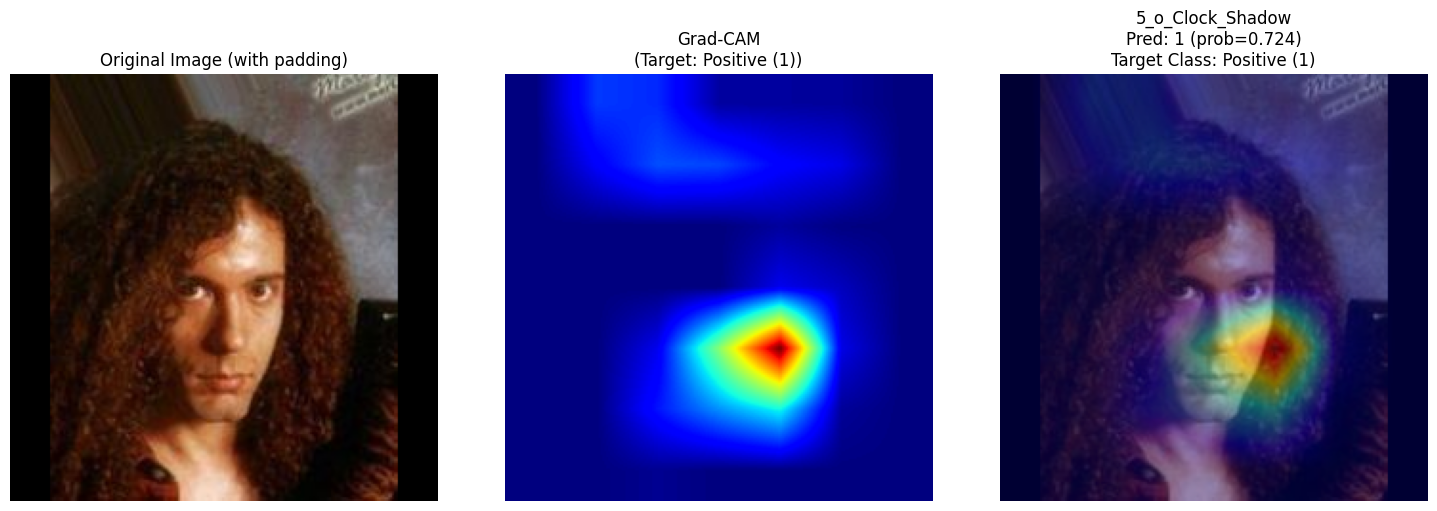

In [14]:
# Choose attribute to visualize
attr_idx = attribute_names.index("5_o_Clock_Shadow")

print(f"Visualizing Grad-CAM for attribute: {attribute_names[attr_idx]}")

# Visualize for POSITIVE class
print("\n=== Grad-CAM for POSITIVE class ===")
visualize_gradcam(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_layer=model.layer4,
    target_class=1,
    method='gradcam'
)


=== Grad-CAM for NEGATIVE class ===


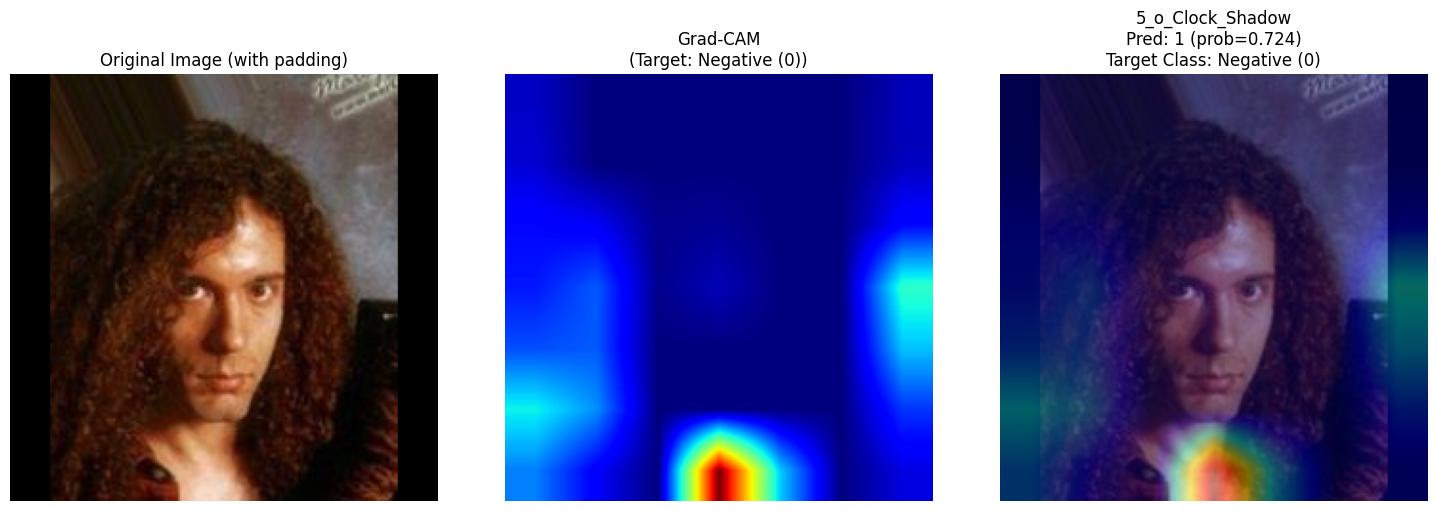

In [15]:
# Visualize for NEGATIVE class
print("\n=== Grad-CAM for NEGATIVE class ===")
visualize_gradcam(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_layer=model.layer4,
    target_class=0,
    method='gradcam'
)

## Grad-CAM++ Visualization

Visualizing Grad-CAM++ for attribute: 5_o_Clock_Shadow

=== Grad-CAM++ for POSITIVE class ===


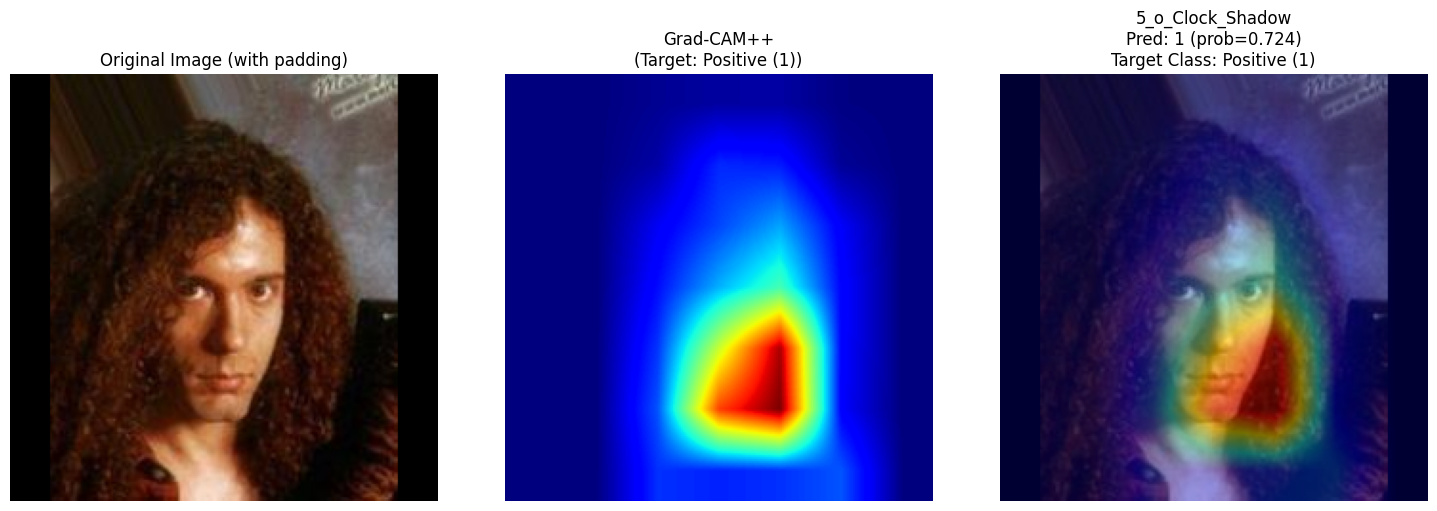

In [16]:
print(f"Visualizing Grad-CAM++ for attribute: {attribute_names[attr_idx]}")

# Visualize for POSITIVE class
print("\n=== Grad-CAM++ for POSITIVE class ===")
visualize_gradcam(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_layer=model.cbam4,
    target_class=1,
    method='gradcam++'
)


=== Grad-CAM++ for NEGATIVE class ===


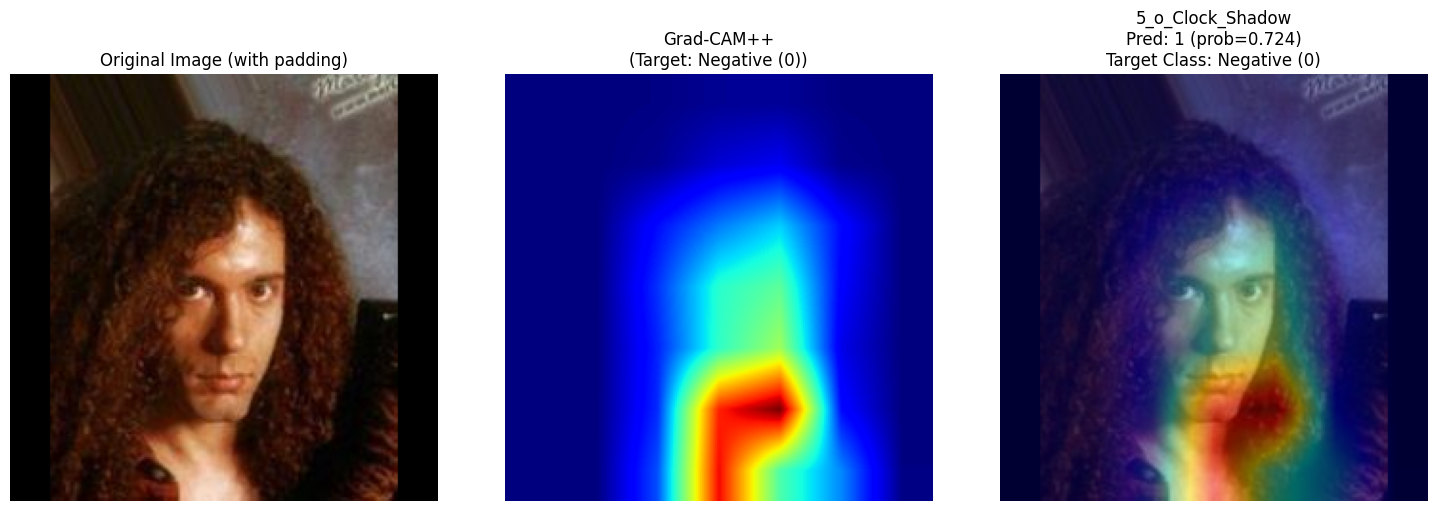

In [17]:
# Visualize for NEGATIVE class
print("\n=== Grad-CAM++ for NEGATIVE class ===")
visualize_gradcam(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_layer=model.cbam4,
    target_class=0,
    method='gradcam++'
)

## Integrated Gradients Visualization

Visualizing Integrated Gradients for attribute: 5_o_Clock_Shadow

=== Integrated Gradients for POSITIVE class ===


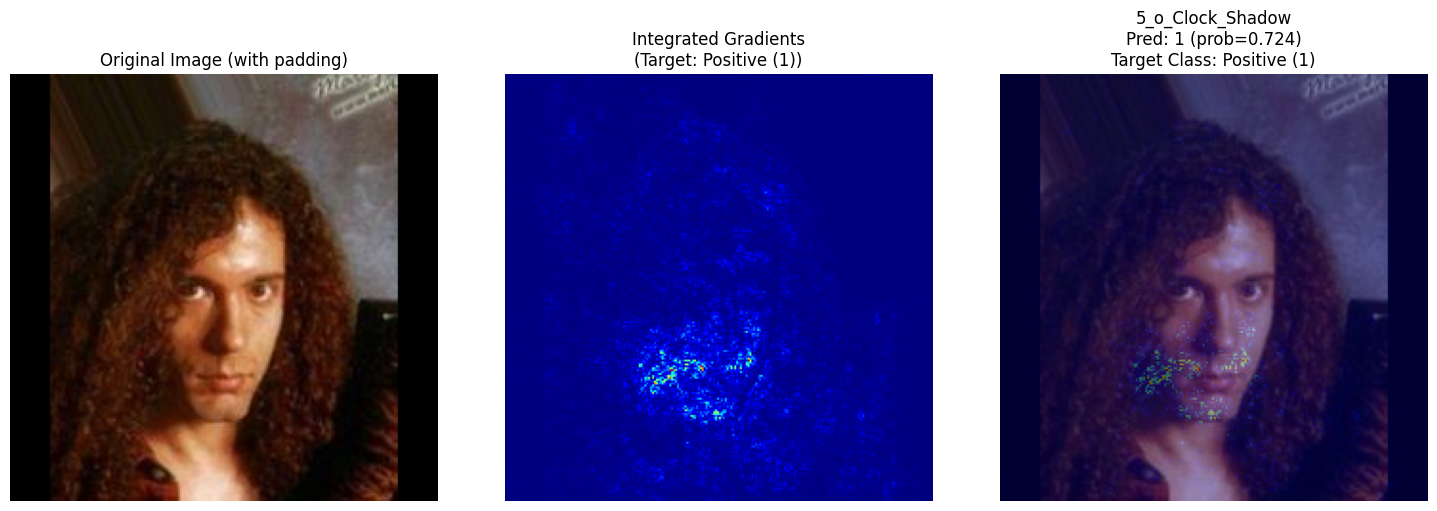

In [18]:
print(f"Visualizing Integrated Gradients for attribute: {attribute_names[attr_idx]}")

# Visualize for POSITIVE class
print("\n=== Integrated Gradients for POSITIVE class ===")
visualize_integrated_gradients(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_class=1,
    steps=50
)


=== Integrated Gradients for NEGATIVE class ===


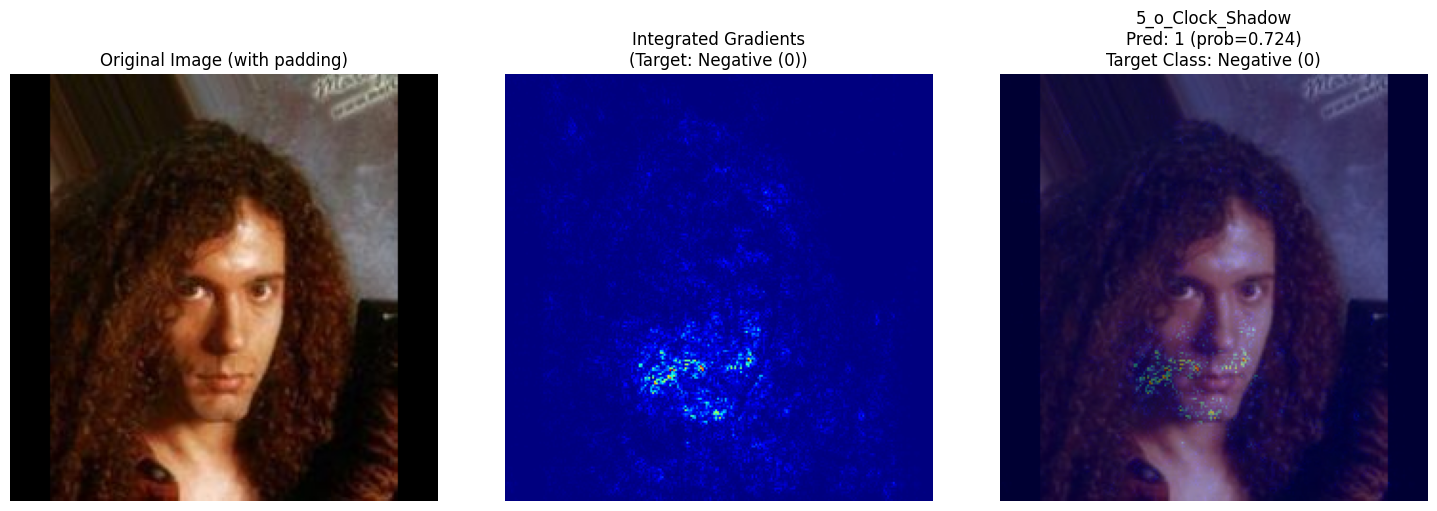

In [19]:
# Visualize for NEGATIVE class
print("\n=== Integrated Gradients for NEGATIVE class ===")
visualize_integrated_gradients(
    model=model,
    image_path=sample_img_path,
    attribute_idx=attr_idx,
    attribute_name=attribute_names[attr_idx],
    transform=val_transform,
    viz_transform=viz_transform,
    device=DEVICE,
    target_class=0,
    steps=50
)